In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from scipy.stats import norm
import warnings
import random

warnings.filterwarnings('ignore')

In [27]:
n_samples = 100
mu1, sigma1 = -5, 1.2
mu2, sigma2 = 5, 1.8
mu3, sigma3 = 0, 1.6

x1 = np.random.normal(loc = mu1, scale = np.sqrt(sigma1), size = n_samples)
x2 = np.random.normal(loc = mu2, scale = np.sqrt(sigma2), size = n_samples)
x3 = np.random.normal(loc = mu3, scale = np.sqrt(sigma3), size = n_samples)

X = np.concatenate((x1, x2, x3))

In [28]:
def plot_pdf(mu, sigma, label, alpha = 0.5, linestyle = 'k--', density = True, color = 'green'):

  X = norm.rvs(mu, sigma, size = 1000)

  plt.hist(X, bins = 50, density = density, alpha = alpha, label = label, color = color)

  x = np.linspace(X.min(), X.max(), 1000)
  y = norm.pdf(x, mu, sigma)
  plt.plot(x, y, linestyle)


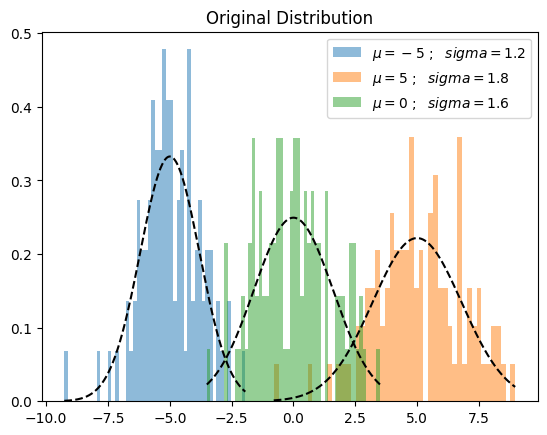

In [29]:
plot_pdf(mu1, sigma1, label = r"$\mu = {} \ ; \ \ sigma = {}$".format(mu1,sigma1), color = None)
plot_pdf(mu2, sigma2, label = r"$\mu = {} \ ; \ \ sigma = {}$".format(mu2,sigma2), color = None)
plot_pdf(mu3, sigma3, label = r"$\mu = {} \ ; \ \ sigma = {}$".format(mu3,sigma3), color = None)
plt.title("Original Distribution")
plt.legend()
plt.show()

In [37]:
def random_init(n_components):

  pi = np.ones((n_components)) / n_components
  means = np.random.choice(X, n_components)
  variances = np.random.random_sample(size = n_components)
  plot_pdf(means[0], variances[0], 'Random Init 01',)
  plot_pdf(means[1], variances[1], 'Random Init 01', color = 'blue')
  plot_pdf(means[2], variances[2], 'Random Init 01', color = 'orange')

  plt.title("Random Initialization")
  plt.legend()
  plt.show()

  return means, variances, pi

In [31]:
def step_expectation(X, n_components, means, variances):
  weights = np.zeros((n_components, len(X)))
  for j in range(n_components):
    weights[j, :] = norm(loc = means[j], scale = np.sqrt(variances[j])).pdf(X)
  return weights

In [32]:
def step_maximaization(X, weights, means, variances, n_components, pi):

  r = []
  for j in range(n_components):
    r.append((weights[j] * pi[j]) / (np.sum([weights[i] *pi[i] for i in range(n_components)],axis = 0)))

    means[j] = np.sum(r[j] * X) / (np.sum(r[j]))
    variances[j] = np.sum(r[j] * np.square(X - means[j])) / (np.sum(r[j]))

    pi[j] = np.mean(r[j])
  return variances, means, pi


In [33]:
def plot_intermediate_steps(means, variances, density = False, save =False, file_name = None):

  plot_pdf(mu1, sigma1, linestyle='r--', label = "Original Distributions")
  plot_pdf(mu2, sigma2, linestyle='r--', label = "Original Distributions")
  plot_pdf(mu3, sigma3, linestyle='r--', label = "Original Distributions")

  color_gen = (x for x in ['green', 'blue', 'orange'])
  for mu, sigma in zip(means, variances):
    plot_pdf(mu, sigma, alpha = 0.5, label = 'd', color = next(color_gen))
  if save or file_name is not None:
    step = file_name.split("_")[1]
    plt.title(f"step: {step}")
    plt.savefig(f"steps/{file_name}.png",bbox_inches = 'tight')
  plt.show()

In [39]:
def train_gmm(data, n_components = 3, n_steps = 50, plot_intermediate_steps_flag = True):

  means, variances, pi = random_init(n_components)
  for step in range(n_steps):
    weights = step_expectation(data, n_components, means, variances)
    variances, means, pi = step_maximaization(X, weights, means, variances, n_components, pi)
    if plot_intermediate_steps_flag:plot_intermediate_steps(means, variances,)
  plot_intermediate_steps(means, variances)

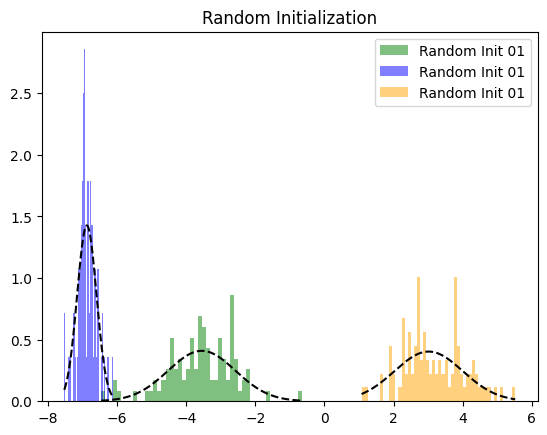

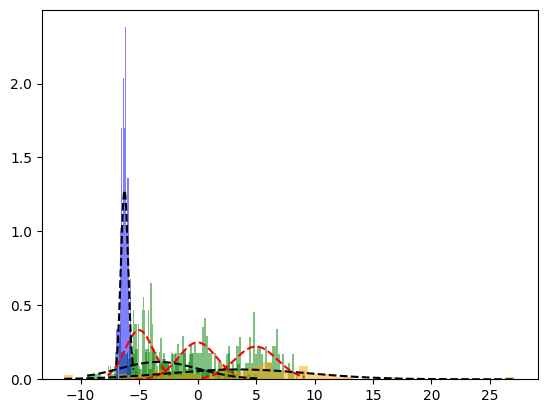

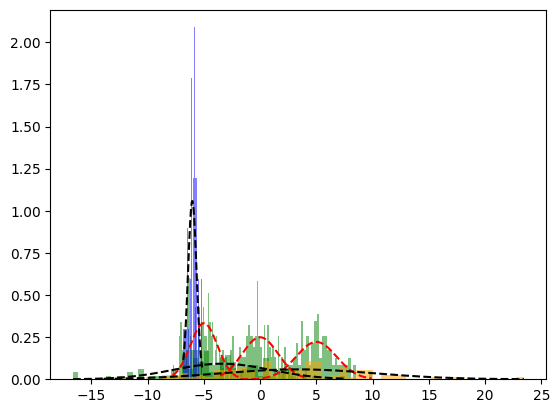

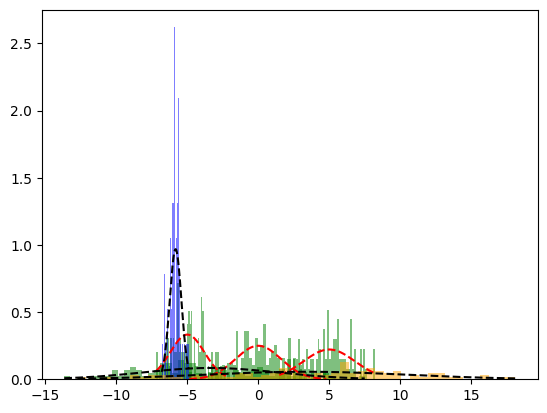

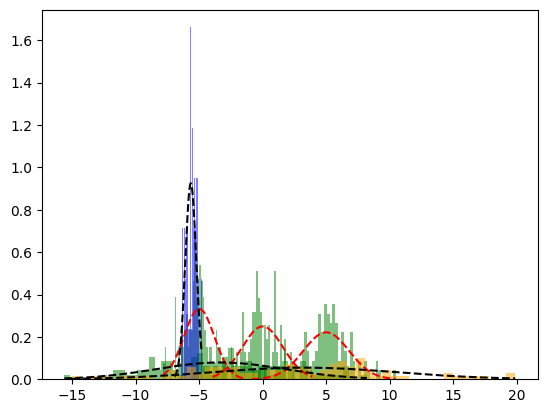

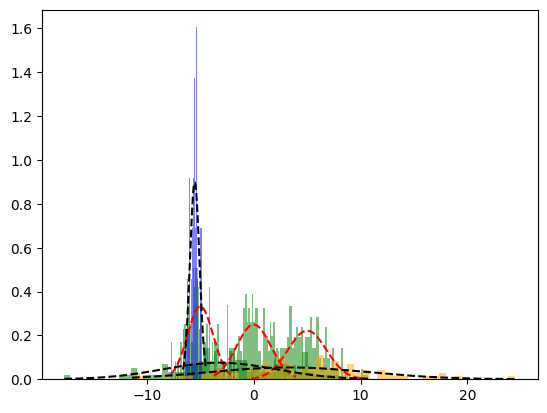

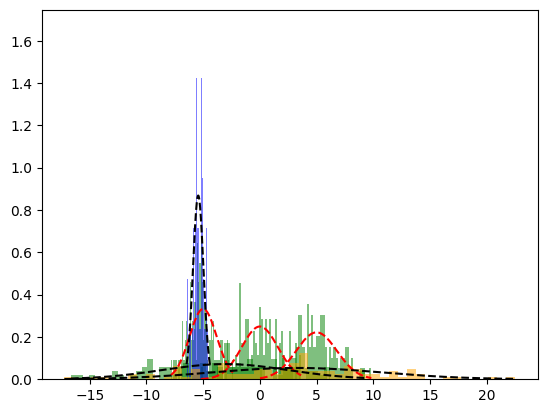

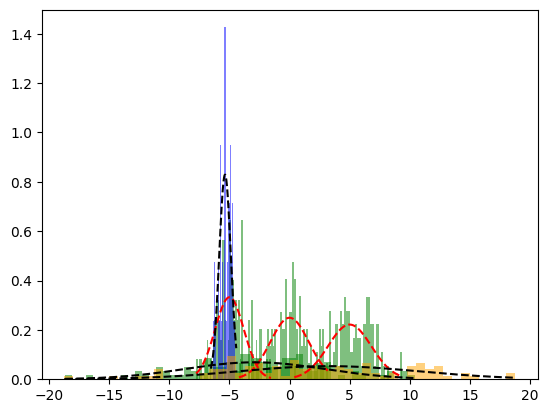

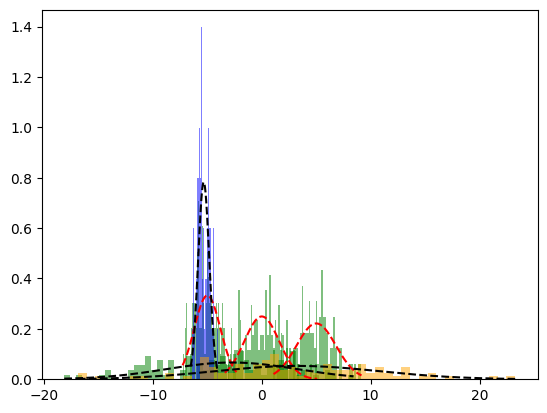

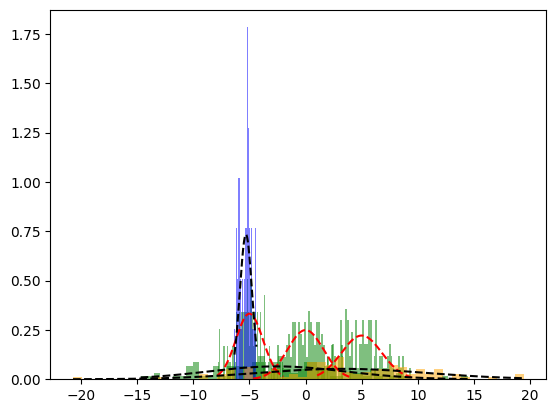

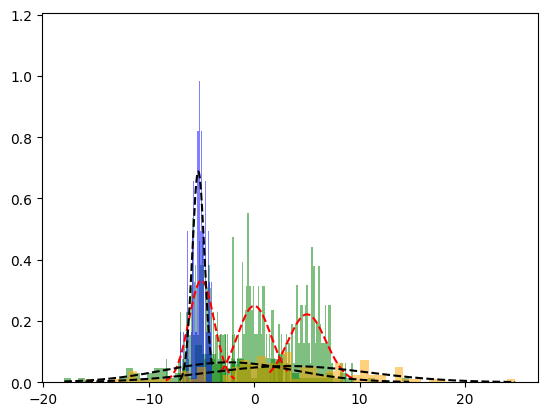

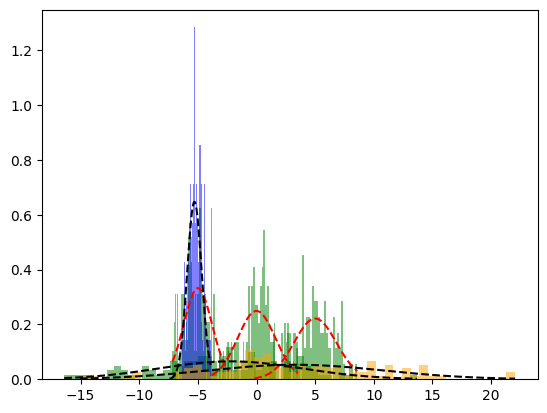

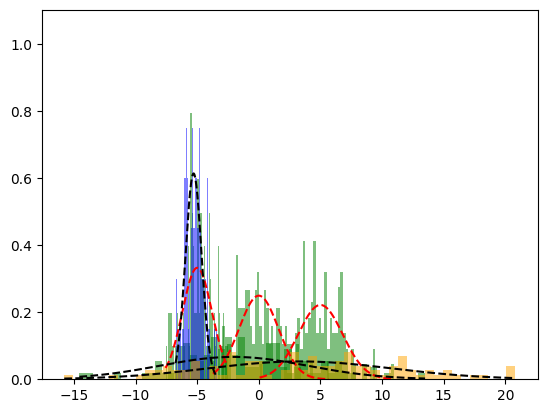

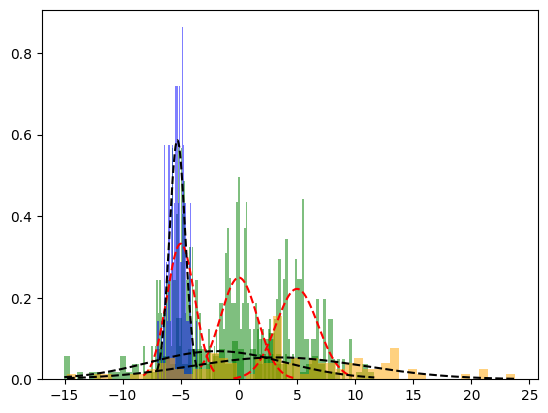

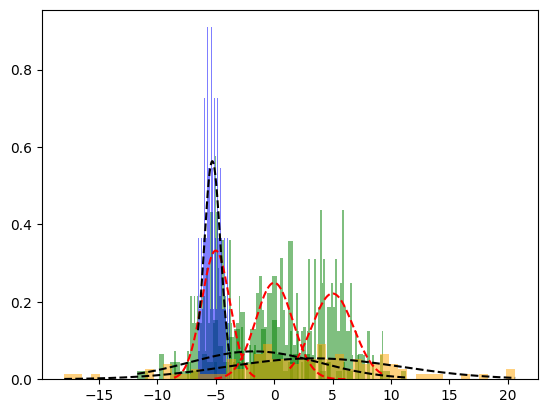

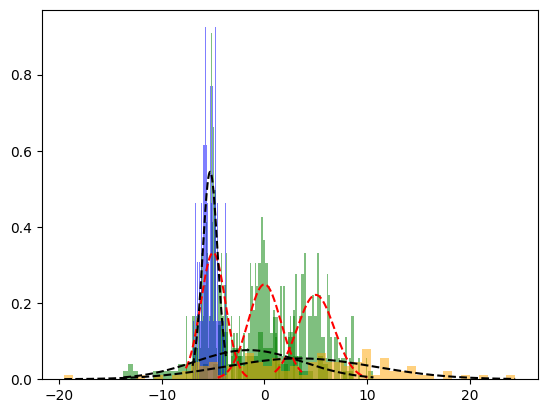

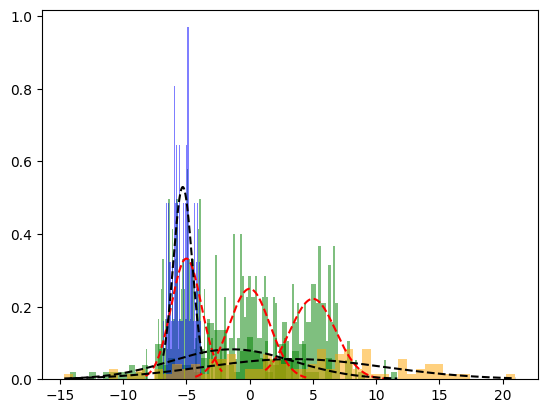

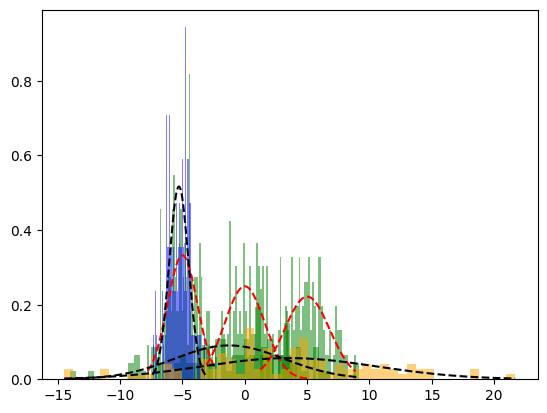

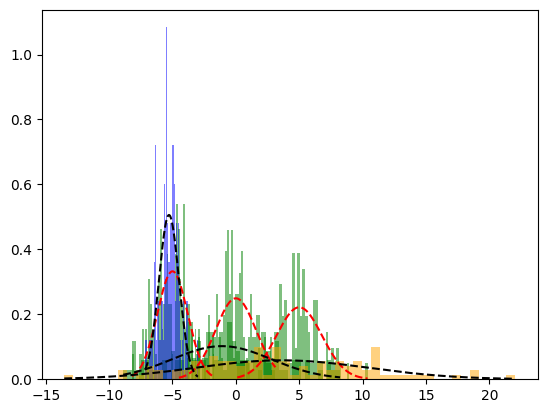

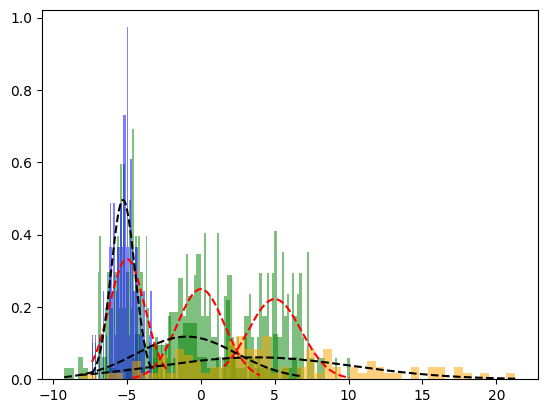

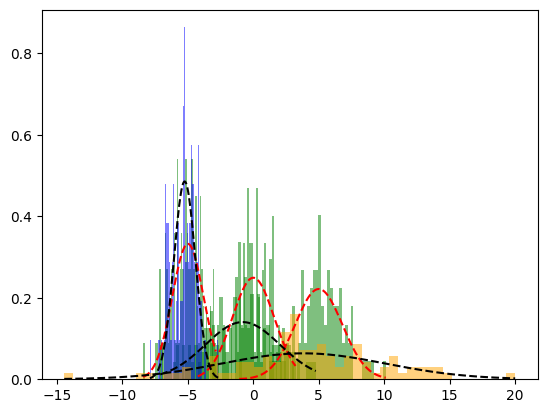

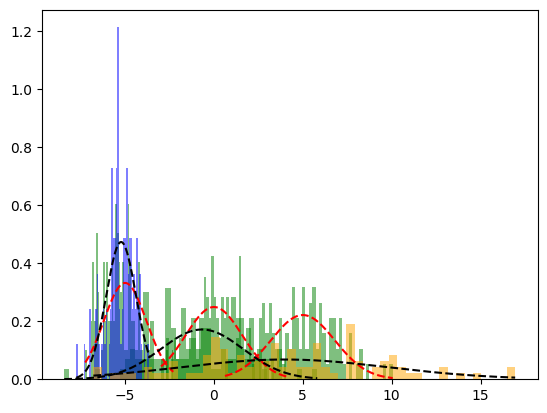

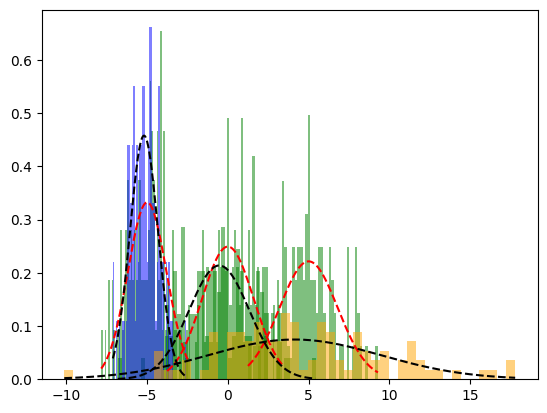

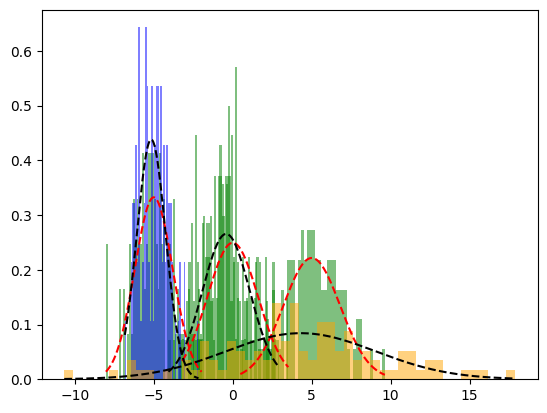

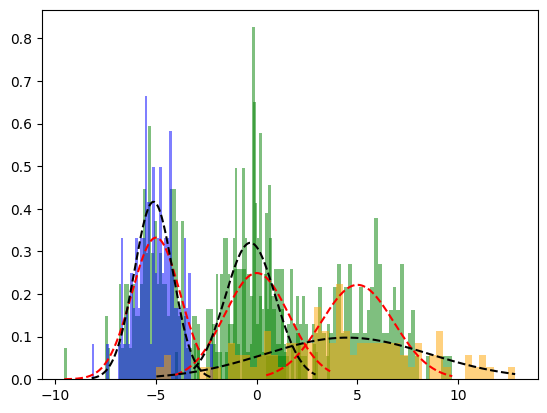

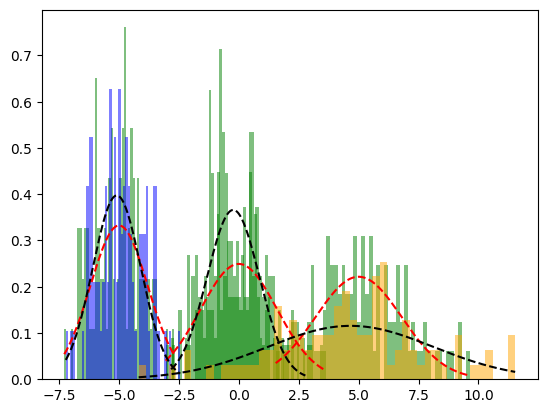

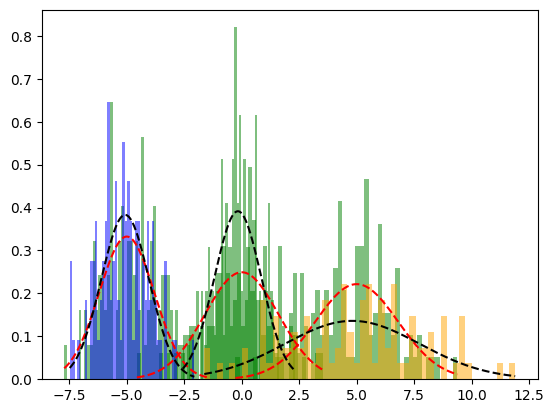

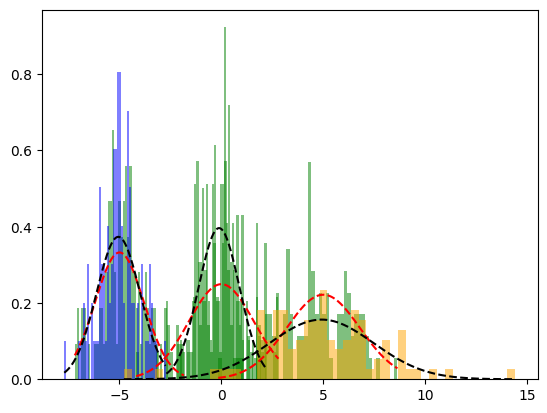

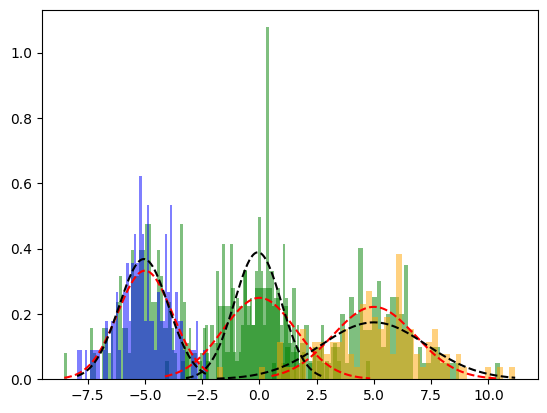

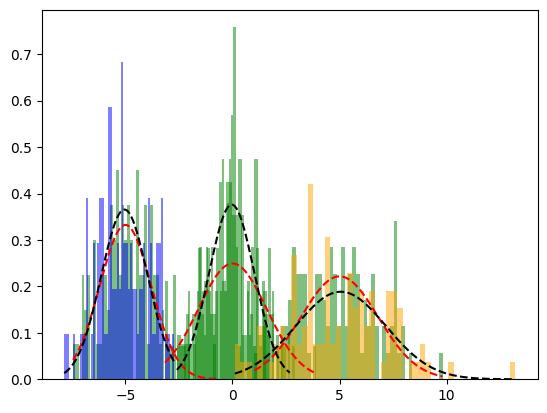

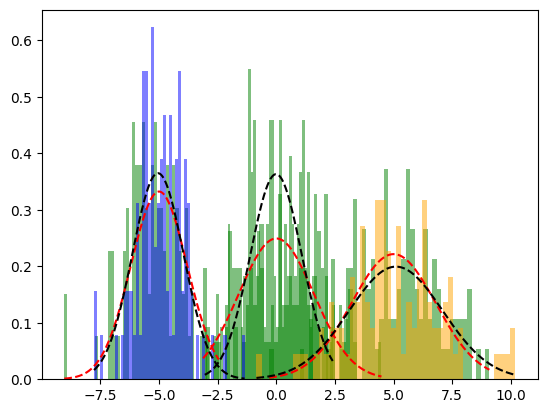

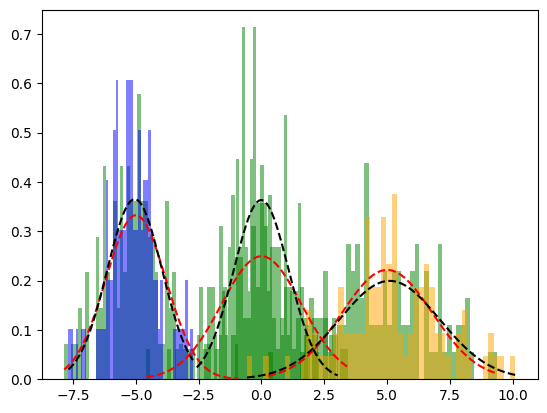

In [40]:
train_gmm(X, n_steps = 30, plot_intermediate_steps_flag = True)